<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana8/teste3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 8.1 MB/s eta 0:00:00


In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Carregando a arquitetura YOLO-World de vocabulário aberto
# O YOLO-World dispensa treinamento pesado para novos objetos: ele usa IA generativa textual ("Zero-Shot")
modelo_world = YOLO('yolov8x-world.pt')

# 2. DEFININDO APENAS UMA CLASSE ÚNICA (Remove a ambiguidade de múltiplas classes)
# É aqui que "configuramos" o que o modelo deve procurar na imagem usando texto puro:
classe_alvo = ["clock","carro"] # Alterado para relógio de pulso (ou mude para o objeto da sua foto)
modelo_world.set_classes(classe_alvo)

print(f"[CONFIGURAÇÃO] O modelo agora está focado exclusivamente em caçar: {classe_alvo}")



Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 18 packages in 763ms
Prepared 2 packages in 3.26s
Installed 2 packages in 2ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@a13192f8cb767260d7dfd98c843b0716593169e7)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 4.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 137MiB/s]


[CONFIGURAÇÃO] O modelo agora está focado exclusivamente em caçar: ['clock', 'carro']


In [31]:
classe_alvo = ["car","wristwatch","man"] # Alterado para relógio de pulso (ou mude para o objeto da sua foto)
modelo_world.set_classes(classe_alvo)


[LAUDO TÉCNICO] Total de correspondências: 3
  -> Alvo 1: Certeza de 86.53% | Coordenadas Pascal VOC: [179, 107, 779, 520]
  -> Alvo 2: Certeza de 72.65% | Coordenadas Pascal VOC: [0, 2, 780, 520]
  -> Alvo 3: Certeza de 63.40% | Coordenadas Pascal VOC: [513, 397, 566, 469]


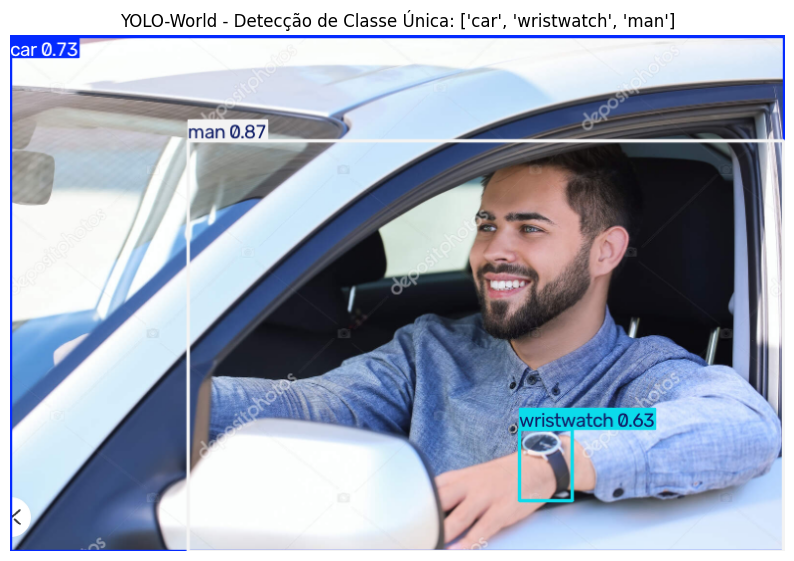

In [32]:
# 3. Caminho da imagem enviada por você para o teste
caminho_foto = "Captura de tela 2026-09-22 214054.png" # Substitua pelo nome exato do arquivo enviado no Colab

# 4. Executando a predição com controle refinado de limiar (conf)
# Reduzir o ruído de fundo e focar em uma única categoria melhora drasticamente o ajuste da caixa
resultados = modelo_world.predict(source=caminho_foto, conf=0.25, verbose=False)
resultado = resultados[0]

print(f"\n[LAUDO TÉCNICO] Total de correspondências: {len(resultado.boxes)}")

for i, box in enumerate(resultado.boxes):
    confianca = box.conf[0].item()
    coordenadas = box.xyxy[0].cpu().numpy().astype(int)
    print(f"  -> Alvo {i+1}: Certeza de {confianca*100:.2f}% | Coordenadas Pascal VOC: {coordenadas.tolist()}")

# 5. Renderização visual limpa e profissional
imagem_final = cv2.cvtColor(resultado.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(imagem_final)
plt.title(f"YOLO-World - Detecção de Classe Única: {classe_alvo}")
plt.axis('off')
plt.show()